# GAN 

I've chosen to implement a Conditional GAN to be able to better steer the generation of datapoints. 
The discriminator is then a binary classifier $d(y, x_i)$ mapping to a number between 0 and 1 signifying whether it thinks the data is real or fake.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import util
import random

original_train = pd.read_pickle('../../data/train.pickle')
original_test = pd.read_pickle('../../data/test.pickle')
train_dataset = util.create_dataset(original_train)
test_dataset = util.create_dataset(original_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

from gan_models import CNNDiscriminator as Discriminator # MLPGenerator is a drop in replacement
from gan_models import CNNGenerator as Generator # MLPDiscriminator is a drop in replacement

N_LABEL = 4
N_NOISE = 10
N_OUTPUTS = train_dataset.tensors[0].shape[1]
OUTPUT_DIM = train_dataset.tensors[0].shape[2]

generator = Generator(N_LABEL, N_NOISE, N_OUTPUTS, OUTPUT_DIM) 
discriminator = Discriminator(N_LABEL, N_OUTPUTS, OUTPUT_DIM) #

criterion = torch.nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=0.001)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=0.0005)


FileNotFoundError: [Errno 2] No such file or directory: '../data/train.pickle'

## Utility functions

In [2]:

def get_incorrect_labels(correct_labels, possible_labels):
    incorrect_labels = []

    for label in correct_labels:
        while True:
            random_label = random.choice(possible_labels)
            if not torch.equal(label, random_label):
                break

        incorrect_labels.append(random_label)

    return torch.stack(incorrect_labels, dim=0)

def generate_fake_samples(generator, batch_size, label_dim, noise_dim, device, labels=None):
    if labels is None:
        labels = torch.Tensor([util.label_to_tuple(random.randint(0, 11)) for _ in range(batch_size)]).to(device)

    noise = torch.randn(batch_size, noise_dim).to(device)
    fake_data = generator(noise, labels)
    return fake_data, labels


## Training Loop

As we are developing a Conditional GAN, the discriminator must learn to both distinguish real and fake samples and to learn whether a sample matches it's label or not. 

This means it will be trained on the following data:
1) real data with the original labels from training data
2) real data with a modified label from the training data
3) fake data made by the generator with respect to a certain label

I will make the proportion of each type of data a constant hyperparameter.




In [ ]:
def train_gan(generator, discriminator, train_loader, criterion, optimizer_g, optimizer_d,
              label_dim, noise_dim, num_epochs=50, 
              alpha_real_correct=1.0, alpha_real_incorrect=1.0, alpha_fake=1.0, 
              device='cuda' if torch.cuda.is_available() else 'cpu'):
    print("Starting GAN training with device:", device)
    generator.to(device)
    discriminator.to(device)


    POSSIBLE_LABELS = [torch.Tensor(util.label_to_tuple(i)).to(device) for i in range(12)]

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        total_loss_d = 0.0
        total_loss_g = 0.0
        batch_count = 0

        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for i, (real_data, real_labels) in enumerate(train_loader):
            

            batch_size = real_data.size(0)
            real_data, real_labels = real_data.to(device), real_labels.to(device)

            # Discriminator
            discriminator.zero_grad()

            # 1. Real data with correct labels
            valid = torch.ones(batch_size, 1).to(device)
            pred_real = discriminator(real_data, real_labels)
            loss_real = criterion(pred_real, valid * 0.95)  # Use label smoothing

            # 2. Real data with incorrect labels
            wrong_labels = get_incorrect_labels(real_labels, POSSIBLE_LABELS).to(device)
            fake = torch.zeros(batch_size, 1).to(device)
            pred_wrong = discriminator(real_data, wrong_labels)
            loss_wrong = criterion(pred_wrong, fake)
            
            # 3. Fake data with correct labels
            fake_data, fake_labels = generate_fake_samples(generator, batch_size, label_dim, noise_dim, device)
            pred_fake = discriminator(fake_data.detach(), fake_labels)
            loss_fake = criterion(pred_fake, fake)

            # Update discriminator
            loss_d = alpha_real_correct * loss_real + alpha_real_incorrect * loss_wrong + alpha_fake * loss_fake

            loss_d.backward()
            optimizer_d.step()

            # Generator
            generator.zero_grad()
            noise = torch.randn(batch_size, noise_dim).to(device)
            fake_data = generator(noise, real_labels)
            pred_fake_for_g = discriminator(fake_data, real_labels)
            loss_g = criterion(pred_fake_for_g, valid)
            loss_g.backward()
            optimizer_g.step()

            # Accumulate losses
            total_loss_d += loss_d.item()
            total_loss_g += loss_g.item()
            batch_count += 1
        avg_loss_d = total_loss_d / batch_count
        avg_loss_g = total_loss_g / batch_count
        print(f"→ Epoch {epoch+1} Summary: Loss_D = {avg_loss_d:.4f}, Loss_G = {avg_loss_g:.4f}")

train_gan(generator, discriminator, train_loader, criterion, optimizer_g, optimizer_d,
          label_dim=N_LABEL, noise_dim=N_NOISE, num_epochs=250, 
          alpha_real_correct=1.0, alpha_real_incorrect=1.0, alpha_fake=1.0)

torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')


## Inference demo

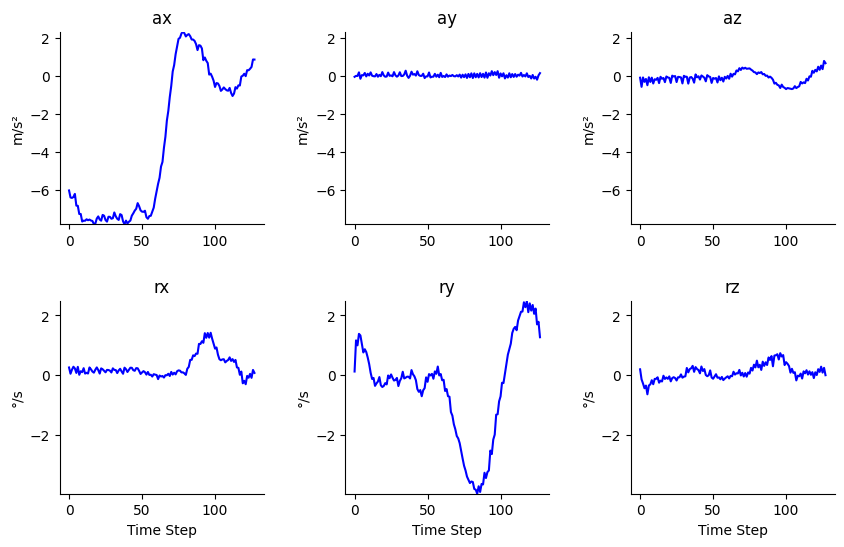

In [3]:
import visualize
import random

# Load the trained generator and discriminator
generator = Generator(N_LABEL, N_NOISE, N_OUTPUTS, OUTPUT_DIM)
discriminator = Discriminator(N_LABEL, N_OUTPUTS, OUTPUT_DIM)

generator.load_state_dict(torch.load('generator.pth'))
discriminator.load_state_dict(torch.load('discriminator.pth'))
generator.eval()
discriminator.eval()


fake_data, fake_labels = generate_fake_samples(generator, 4053, N_LABEL, N_NOISE, device='cpu')
visualize.plot_data(fake_data.detach().numpy()[0])



## Create extended dataset

In [ ]:

import util

s = util.package_fake_series(fake_data, fake_labels, original_train)
print(fake_data.shape)
s = pd.concat((s, original_train))

s.to_pickle('fake_data.pickle')
s


,sensor_data,label,model,deceleration_average,velocity,mass
0,"[[-6.032522, -0.048960924, -0.097358465, 0.254...",11,Fake Car 9000,-4.957158,20.0,1341.0
1,"[[-4.9834867, 0.083302915, 0.059475716, 0.2321...",7,Fake Car 9000,-4.957158,20.0,1341.0
2,"[[-5.211684, 0.04018219, 0.0020328425, 0.19842...",9,Fake Car 9000,-4.957158,20.0,1341.0
3,"[[-6.267665, -0.04656034, -0.09507712, 0.24538...",11,Fake Car 9000,-4.957158,20.0,1341.0
4,"[[-5.4653664, -0.02186662, -0.13536352, 0.1513...",6,Fake Car 9000,-4.957158,20.0,1341.0
...,...,...,...,...,...,...
4048,"[[-5.324453704687594, -0.15054797322465596, -0...",4,Variant Comfortline,-4.794934,20.0,1530.0
4049,"[[-6.606383663551209, -0.36275289291536233, 0....",4,Variant Comfortline,-5.272853,20.0,1530.0
4050,"[[-5.7613776142408755, -0.29543847657441596, 0...",4,Variant Comfortline,-4.844974,20.0,1530.0
4051,"[[-5.357791872121975, -0.34445334501254266, 0....",4,Variant Comfortline,-5.327936,20.0,1530.0
